# 다중클래스분류_callback사용해_과적합_막고_최고성능모델_저장하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("./data/winequality-white.csv", sep=";")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


<Axes: >

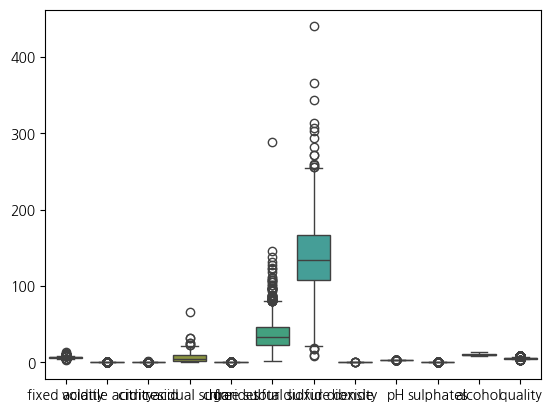

In [4]:
sns.boxplot(data)

In [5]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [7]:
X = data.drop('quality', axis=1)
y = data['quality']

In [8]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [9]:
y

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [10]:
y = pd.get_dummies(y)
y

,3,4,5,6,7,8,9
0,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
4893,False,False,False,True,False,False,False
4894,False,False,True,False,False,False,False
4895,False,False,False,True,False,False,False
4896,False,False,False,False,True,False,False


In [11]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [14]:
y_valid

,3,4,5,6,7,8,9
2292,False,False,False,True,False,False,False
2587,False,False,False,True,False,False,False
4596,False,False,False,True,False,False,False
1458,False,False,False,True,False,False,False
873,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...
4606,False,False,True,False,False,False,False
4310,False,False,False,True,False,False,False
855,False,False,False,False,True,False,False
2716,False,False,True,False,False,False,False


In [15]:
rs = RobustScaler()
train_temp = rs.fit_transform(X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)
rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index= X_train.index)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index= X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index= X_test.index)

In [16]:
rs_X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3940,0.090909,1.272727,0.416667,0.451220,0.714286,0.090909,0.216667,0.507205,-0.05,0.142857,-0.578947
3905,-0.272727,0.636364,-0.166667,-0.170732,-0.500000,0.000000,-0.783333,-0.811527,0.40,1.071429,1.105263
53,-0.363636,-0.727273,0.250000,-0.512195,0.142857,0.227273,-0.450000,-0.622478,0.70,-0.928571,0.263158
2576,-0.272727,0.090909,0.666667,0.585366,-0.285714,1.818182,1.533333,0.465706,0.05,0.142857,-0.526316
1970,1.363636,2.090909,0.916667,-0.329268,-0.500000,-0.090909,-0.316667,0.138329,0.30,-0.071429,0.157895
...,...,...,...,...,...,...,...,...,...,...,...
2609,0.272727,-0.545455,-0.166667,-0.524390,-1.714286,-1.363636,-1.783333,-1.035159,0.15,-0.857143,0.842105
2530,-0.909091,0.363636,-1.666667,-0.439024,-0.500000,1.045455,0.466667,-0.325072,1.05,0.785714,0.052632
1231,1.000000,1.363636,0.416667,-0.085366,-0.928571,0.272727,-0.350000,-0.414986,0.00,0.428571,1.052632
3948,-1.000000,-1.090909,-0.166667,0.024390,0.142857,-0.363636,-0.500000,0.205187,0.75,-0.214286,-0.578947


In [18]:
y_train.shape[1]

7

In [19]:
y_train

,3,4,5,6,7,8,9
3940,False,False,True,False,False,False,False
3905,False,False,False,False,True,False,False
53,False,False,False,True,False,False,False
2576,False,False,True,False,False,False,False
1970,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
2609,False,False,False,True,False,False,False
2530,False,False,False,True,False,False,False
1231,False,False,False,False,True,False,False
3948,False,False,True,False,False,False,False


In [20]:
rs_X_train.shape[1]

11

# 모델을 최고 성능에서 저장하고 중지하기

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [23]:
data['quality'].nunique()

7

In [25]:
n_class = y_train.shape[1]
model = Sequential()
model.add(Input(shape=(rs_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(n_class, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
import os

Epoch 1/1000


I0000 00:00:1747318284.299166   25286 service.cc:152] XLA service 0x7f131000a020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747318284.299209   25286 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 23:11:24.322050: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747318284.460845   25286 cuda_dnn.cc:529] Loaded cuDNN version 90300


58/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3862 - loss: 1.6759

I0000 00:00:1747318285.866398   25286 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4080 - loss: 1.6102 - val_accuracy: 0.5102 - val_loss: 1.2851
Epoch 2/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5111 - loss: 1.2244 - val_accuracy: 0.5296 - val_loss: 1.1907
Epoch 3/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5283 - loss: 1.1552 - val_accuracy: 0.5378 - val_loss: 1.1452
Epoch 4/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5576 - loss: 1.0719 - val_accuracy: 0.5408 - val_loss: 1.1159
Epoch 5/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5551 - loss: 1.0490 - val_accuracy: 0.5347 - val_loss: 1.1125
Epoch 6/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5553 - loss: 1.0661 - val_accuracy: 0.5429 - val_loss: 1.1031
Epoch 7/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5559 - loss: 1.0689 - val_accuracy: 0.5337 - val_loss: 1.0909
Epoch 8/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5763 - loss: 1.0120 - val_accuracy: 0.5510 - val_l

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6731 - loss: 0.7556 - val_accuracy: 0.5490 - val_loss: 1.1800
Epoch 52/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6863 - loss: 0.7516 - val_accuracy: 0.5571 - val_loss: 1.1507
Epoch 53/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6881 - loss: 0.7377 - val_accuracy: 0.5480 - val_loss: 1.1574
Epoch 54/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6866 - loss: 0.7463 - val_accuracy: 0.5490 - val_loss: 1.1589
Epoch 55/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7079 - loss: 0.7060 - val_accuracy: 0.5612 - val_loss: 1.1625
Epoch 56/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6772 - loss: 0.7584 - val_accuracy: 0.5551 - val_loss: 1.2277
Epoch 57/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6770 - loss: 0.7288 - val_accuracy: 0.5704 - val_loss: 1.1615
Epoch 58/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6904 - loss: 0.7287 - val_accuracy: 0.5633 -

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7751 - loss: 0.5788 - val_accuracy: 0.5184 - val_loss: 1.3778
Epoch 102/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7569 - loss: 0.5699 - val_accuracy: 0.5276 - val_loss: 1.3895
Epoch 103/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7728 - loss: 0.5619 - val_accuracy: 0.5480 - val_loss: 1.3952
Epoch 104/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7769 - loss: 0.5528 - val_accuracy: 0.5561 - val_loss: 1.4118
Epoch 105/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7598 - loss: 0.5754 - val_accuracy: 0.5388 - val_loss: 1.3949
Epoch 106/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7782 - loss: 0.5575 - val_accuracy: 0.5510 - val_loss: 1.4868
Epoch 107/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7706 - loss: 0.5678 - val_accuracy: 0.5561 - val_loss: 1.5021
Epoch 108/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7912 - loss: 0.5556 - val_accuracy: 0

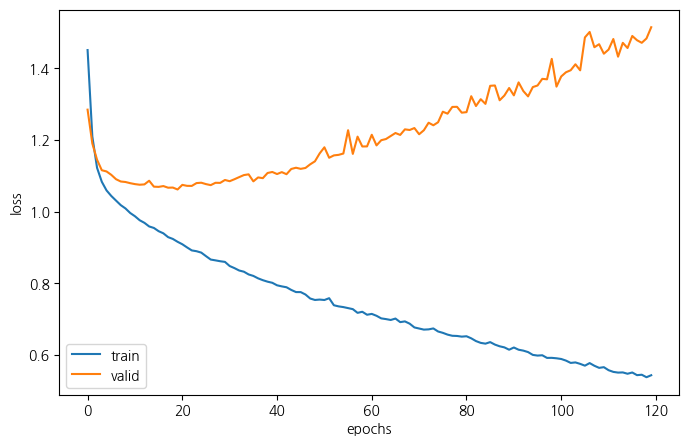

In [27]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=100)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동 생성
filepath = "./model/witewine_loss_{val_loss:.4f}_epoch_{epoch:04d}__.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model.fit(rs_X_train, y_train,
                   epochs=1000,
                   batch_size=32,
                   validation_data=(rs_X_valid, y_valid),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

In [28]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

# 데이터 증폭 후 분석
* 데이터 증폭 + 스케일러 사용시
* 데이터 증폭 후 스케일러로 스케일링

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [31]:
X = data.drop('quality', axis=1)
y = data['quality']

In [32]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [33]:
print(y_train.nunique())
print(y_valid.nunique())
print(y_test.nunique())

7
7
7


In [34]:
smt = SMOTE(k_neighbors=2, random_state=42)
smt_X_train, smt_y_train = smt.fit_resample(X_train, y_train)
smt_X_train = pd.DataFrame(smt_X_train, columns=X_train.columns)
smt_y_train = pd.Series(smt_y_train)

/home/fintech/miniforge3/envs/tf/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [35]:
smt_X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.800000,0.210000,0.270000,2.100000,0.030000,26.000000,139.000000,0.990000,3.160000,0.610000,12.600000
1,6.700000,0.240000,0.320000,10.300000,0.079000,37.000000,122.000000,0.996620,3.020000,0.450000,8.800000
2,7.600000,0.270000,0.420000,2.600000,0.044000,29.000000,110.000000,0.991200,3.310000,0.510000,12.700000
3,7.000000,0.150000,0.280000,14.700000,0.051000,29.000000,149.000000,0.997920,2.960000,0.390000,9.000000
4,7.500000,0.170000,0.340000,1.400000,0.035000,13.000000,102.000000,0.991800,3.050000,0.740000,11.000000
...,...,...,...,...,...,...,...,...,...,...,...
9221,7.390043,0.240664,0.364315,2.006638,0.031033,27.132757,138.137077,0.990542,3.282987,0.478009,12.513276
9222,6.751973,0.329605,0.350789,1.782368,0.024343,26.127625,93.510499,0.989848,3.397842,0.552250,12.551973
9223,6.773419,0.325316,0.359367,1.808102,0.024815,26.427860,94.711442,0.989875,3.396127,0.544101,12.573419
9224,6.630848,0.353830,0.302339,1.637017,0.021679,24.431866,86.727465,0.989690,3.407532,0.598278,12.430848


In [36]:
smt_y_train.value_counts()

quality
7    1318
5    1318
6    1318
4    1318
8    1318
3    1318
9    1318
Name: count, dtype: int64

In [37]:
rs = RobustScaler()
train_temp = rs.fit_transform(smt_X_train)
valid_temp = rs.transform(X_valid)
test_temp = rs.transform(X_test)
rs_X_train = pd.DataFrame(train_temp, columns=X_train.columns)
rs_X_valid = pd.DataFrame(valid_temp, columns=X_valid.columns, index= X_valid.index)
rs_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index= X_test.index)

In [38]:
ot_smt_y_train = pd.get_dummies(smt_y_train)
ot_smt_y_train

,3,4,5,6,7,8,9
0,False,False,False,False,True,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
9221,False,False,False,False,False,False,True
9222,False,False,False,False,False,False,True
9223,False,False,False,False,False,False,True
9224,False,False,False,False,False,False,True


In [39]:
y_valid = pd.get_dummies(y_valid)
y_valid

,3,4,5,6,7,8,9
2794,False,False,True,False,False,False,False
2860,False,False,False,True,False,False,False
4885,False,False,False,True,False,False,False
2062,False,False,True,False,False,False,False
176,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...
2985,False,False,False,False,True,False,False
4778,False,False,False,True,False,False,False
3841,False,False,False,True,False,False,False
3937,False,False,True,False,False,False,False


In [40]:
y_test = pd.get_dummies(y_test)
y_test

,3,4,5,6,7,8,9
2613,False,False,True,False,False,False,False
2361,False,False,True,False,False,False,False
4245,False,False,True,False,False,False,False
3947,False,False,False,False,True,False,False
3799,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
4502,False,False,False,True,False,False,False
3148,False,False,False,True,False,False,False
1562,False,False,False,False,True,False,False
37,False,False,False,True,False,False,False


In [41]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [42]:
n_class = ot_smt_y_train.shape[1]
model = Sequential()
model.add(Input(shape=(smt_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(n_class, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
import os

Epoch 1/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3510 - loss: 1.6486 - val_accuracy: 0.3357 - val_loss: 1.5318
Epoch 2/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6053 - loss: 0.9873 - val_accuracy: 0.3847 - val_loss: 1.3449
Epoch 3/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6690 - loss: 0.8287 - val_accuracy: 0.3776 - val_loss: 1.3252
Epoch 4/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ -1s -1863us/step - accuracy: 0.6869 - loss: 0.7679 - val_accuracy: 0.4092 - val_loss: 1.2867
Epoch 5/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6937 - loss: 0.7367 - val_accuracy: 0.4337 - val_loss: 1.2724
Epoch 6/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7130 - loss: 0.6924 - val_accuracy: 0.4367 - val_loss: 1.2692
Epoch 7/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7240 - loss: 0.6733 - val_accuracy: 0.4347 - val_loss: 1.2789
Epoch 8/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7314 - loss: 0.6

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8635 - loss: 0.3445 - val_accuracy: 0.5122 - val_loss: 1.7557
Epoch 51/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8606 - loss: 0.3370 - val_accuracy: 0.5235 - val_loss: 1.7331
Epoch 52/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8714 - loss: 0.3272 - val_accuracy: 0.5112 - val_loss: 1.7472
Epoch 53/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.3237 - val_accuracy: 0.5000 - val_loss: 1.8254
Epoch 54/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.3269 - val_accuracy: 0.5153 - val_loss: 1.7910
Epoch 55/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8680 - loss: 0.3199 - val_accuracy: 0.5061 - val_loss: 1.8130
Epoch 56/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8727 - loss: 0.3180 - val_accuracy: 0.4959 - val_loss: 1.8410
Epoch 57/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8743 - loss: 0.3166 - val_ac

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.2519 - val_accuracy: 0.5378 - val_loss: 2.2763
Epoch 100/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9025 - loss: 0.2516 - val_accuracy: 0.5378 - val_loss: 2.2843
Epoch 101/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.2464 - val_accuracy: 0.5357 - val_loss: 2.2631
Epoch 102/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8968 - loss: 0.2579 - val_accuracy: 0.5255 - val_loss: 2.2857
Epoch 103/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.2391 - val_accuracy: 0.5367 - val_loss: 2.2783
Epoch 104/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ -1s -3127us/step - accuracy: 0.9022 - loss: 0.2450 - val_accuracy: 0.5459 - val_loss: 2.2745
Epoch 105/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.2496 - val_accuracy: 0.5327 - val_loss: 2.3327
Epoch 106/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9049 - loss: 0.2

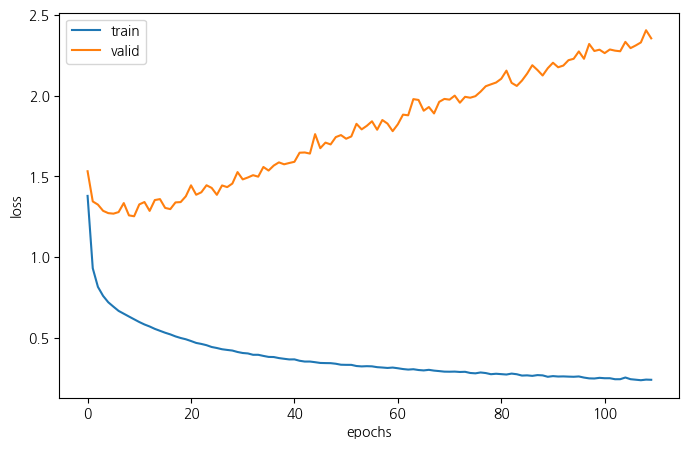

In [44]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=100)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동 생성
filepath = "./model/witewine_loss_{val_loss:.4f}_epoch_{epoch:04d}__.keras"
model_save = ModelCheckpoint(filepath=filepath, save_best_only=True)
history = model.fit(rs_X_train, ot_smt_y_train,
                   epochs=1000,
                   batch_size=32,
                   validation_data=(rs_X_valid, y_valid),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

# 저장된 best 모델 불러와서 사용하기

In [45]:
rs_X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
2613,-0.337800,0.772063,1.752696,1.045876,0.617084,-0.051244,0.242181,0.706733,-0.681818,-0.551977,-0.616379
2361,1.345167,-0.289524,1.208226,0.033782,0.617084,-0.819912,-0.386251,0.492741,0.272727,0.867392,-0.497429
4245,0.714054,0.675555,1.298971,1.555908,-0.136666,0.614934,-0.154723,1.105910,-0.818182,0.236561,-0.695680
3947,-0.863728,0.193016,-0.062203,-0.213265,0.153238,0.563689,0.275256,-0.684214,0.409091,-0.236561,0.692077
3799,0.082941,0.193016,-0.425183,-0.213265,0.153238,-0.461200,0.854075,-0.243885,-0.090909,0.788538,0.176625
...,...,...,...,...,...,...,...,...,...,...,...
4502,0.188127,-0.289524,-0.152948,-0.197326,0.617084,0.102489,0.506784,-0.297383,-0.363636,0.315415,0.176625
3148,-0.758542,-0.482539,0.300776,2.177509,-0.020704,0.358711,0.076804,1.361054,0.045455,-0.315415,-0.854281
1562,0.188127,0.579047,1.480461,-0.324834,-0.716474,-0.204978,0.010653,-0.585448,0.363636,-1.103953,0.493826
37,0.082941,0.482539,-0.062203,-0.372650,0.791027,0.409956,0.209106,-0.461992,-0.409091,-1.498222,0.097324


In [46]:
y_test

,3,4,5,6,7,8,9
2613,False,False,True,False,False,False,False
2361,False,False,True,False,False,False,False
4245,False,False,True,False,False,False,False
3947,False,False,False,False,True,False,False
3799,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
4502,False,False,False,True,False,False,False
3148,False,False,False,True,False,False,False
1562,False,False,False,False,True,False,False
37,False,False,False,True,False,False,False


In [47]:
from keras.models import load_model

In [48]:
best_model = load_model("./model/witewine_loss_1.0622_epoch_0020__.keras")
wine_pred = best_model.predict(rs_X_test)
wine_pred = pd.DataFrame(wine_pred, columns=y_test.columns)
wine_pred

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,3,4,5,6,7,8,9
0,0.002615,0.009180,0.680846,0.296908,0.009596,0.000824,0.000032
1,0.007239,0.127555,0.407515,0.393949,0.055052,0.007838,0.000852
2,0.001278,0.005302,0.581463,0.394767,0.015896,0.001276,0.000017
3,0.004983,0.007012,0.037537,0.370481,0.411413,0.161856,0.006717
4,0.005458,0.022546,0.250220,0.645042,0.073432,0.003081,0.000222
...,...,...,...,...,...,...,...
975,0.006695,0.012759,0.238779,0.598996,0.129242,0.012774,0.000756
976,0.000587,0.000505,0.413400,0.552652,0.030591,0.002259,0.000005
977,0.006569,0.014418,0.023915,0.444312,0.376372,0.123485,0.010929
978,0.007097,0.040858,0.312882,0.568853,0.058001,0.011437,0.000872


In [49]:
best_model.evaluate(rs_X_test, y_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5653 - loss: 1.0636


[1.0480014085769653, 0.5612244606018066]